Today's topics:
* a sum of squared residuals as an objective
* parameters as the variables of `minimize`
* reading several fitted parameters from `res.x`
* comparing `minimize` with `curve_fit`

# How a part crushes

Last time we gave `minimize` an objective with one variable, `x`.
Today the variables are the parameters of a model.
The objective is one number that records the mismatch between a model and the data.
`minimize` adjusts the parameters to reduce it.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/fc/Aluminium_foam.jpg/960px-Aluminium_foam.jpg" alt="A tall rectangular block of aluminium foam standing on a pale surface, its faces covered in rounded pores of many sizes separated by thin metal walls" width=300/>

*Photo by Stehfun, [CC BY 3.0](https://creativecommons.org/licenses/by/3.0), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Aluminium_foam.jpg).*

Above: A block of [aluminium foam](https://en.wikipedia.org/wiki/Metal_foam).
Gas bubbles in the molten metal leave a solid made mostly of pores, so the metal is a thin network of cell walls.

Cellular solids such as foams and printed lattices often show a sequence of three stages under compression.
At first the cell walls bend a little, and the force rises in proportion to the displacement.

Then the walls buckle or yield, and the cells collapse one layer after another.
The force levels off.

Late in the test the collapsed cells press together.
The part behaves like a dense solid, and the force climbs steeply.
This last stage is **densification**.

The printed-part curve from L19 has similar regions.
We use this mechanism as one possible interpretation.
The part's internal architecture is not recorded in the dataset.
The fit returns parameters such as the late-stage growth rate.

The sketch shows the three stages for a cellular solid.
We can reuse the picture from L19 for the force curve itself.

A fit needs a measure of how far a curve sits from the data.
At each reading the **residual** is the measured value minus the model's value.

Positive and negative residuals can cancel in a sum.
Squaring prevents cancellation, and doubling a miss then quadruples its contribution.
The **sum of squared residuals** is the measure we use today.
Fitting by this measure is called **least squares**.

It is still a choice.

`curve_fit` uses least squares.
With `minimize`, we write that objective explicitly and compare the resulting parameters.

# A model as an objective

In L19 we wrote a model function that takes `x` first and then the parameters.
We start with the same toy as in L19, six measurements that fall off with $x$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

def my_model(x, a, b):
    return a * np.exp(-b * x)

x_toy = np.array([0, 1, 2, 3, 4, 5])
y_toy = np.array([4.1, 2.5, 1.6, 1.0, 0.55, 0.4])

`minimize` calls an objective that takes the parameters and returns one number.
The parameters arrive together as one array, as `x` did last time.

Our objective unpacks them, builds the model's curve, subtracts it from the data, squares and adds.
The data arrays are read from the notebook, as `target` was in L21.

In [2]:
def sse_toy(params):
    a, b = params
    y_model = my_model(x_toy, a, b)
    residuals = y_toy - y_model
    return np.sum(residuals**2)

We call it ourselves first, with two sets of trial values.
A small number means the curve sits close to the data.

In [3]:
print(sse_toy([4, 0.5]))
print(sse_toy([3, 0.2]))

0.04872749434767681
2.9305754145926617


The first pair is much closer to the data than the second.
Here is the sum as `b` changes, with `a` held at 4.
Each pass of the loop makes one call to `sse_toy`.

Text(0, 0.5, 'sum of squared residuals')

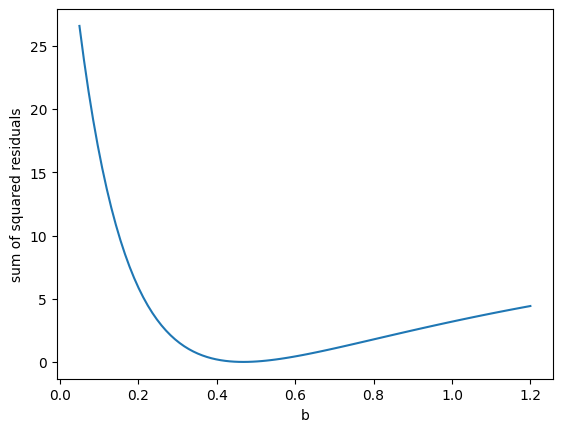

In [4]:
b_list = np.linspace(0.05, 1.2, 100)
sse_list = []
for b_trial in b_list:
    sse_list.append(sse_toy([4, b_trial]))

fig, ax = plt.subplots()
ax.plot(b_list, sse_list)
ax.set_xlabel('b')
ax.set_ylabel('sum of squared residuals')

The curve has one dip, near $b = 0.47$.
A fit means finding the bottom of that dip for $a$ and $b$ together.
That is a job for `minimize`.

# Minimizing over the parameters

The variables of this objective are `a` and `b`.
`x0` has one starting value for each, in the order of the unpack line.

We start at 1 and 1, as `curve_fit` does unless we set `p0`.

In [5]:
res_toy = optimize.minimize(sse_toy, [1, 1])
print(res_toy.x)
print(res_toy.fun)
print(res_toy.success)

[4.09033188 0.47847118]
0.006380521759445006
True


`res.x` has two entries now, `a` first and `b` second, because the unpack line in `sse_toy` puts them in that order.
We unpack the fitted values into names, as we did with `popt`.
`res.fun` is the smallest sum of squared residuals the solver reached.

In [6]:
a_toy, b_toy = res_toy.x
print(f'a = {a_toy:.3f}, b = {b_toy:.3f}')

a = 4.090, b = 0.478


Now the same data and the same model through `curve_fit`.

In [7]:
popt, pcov = optimize.curve_fit(my_model, x_toy, y_toy)
print(f'a = {popt[0]:.3f}, b = {popt[1]:.3f}')

a = 4.090, b = 0.478


The two answers agree to the digits printed.
`curve_fit` minimizes the sum of squared residuals, so it has the same lowest point as our objective.

It also returns `pcov`.
`minimize` returns no `pcov`, so the standard errors from L19 come from `curve_fit`.

Here is the fit on the data.

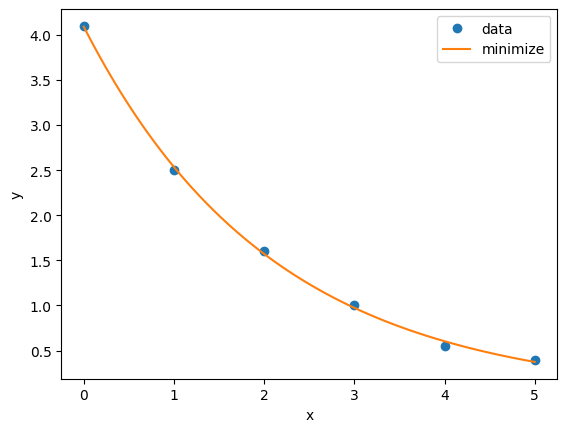

In [8]:
x_line = np.linspace(0, 5, 100)

fig, ax = plt.subplots()
ax.plot(x_toy, y_toy, 'o', label='data')
ax.plot(x_line, my_model(x_line, a_toy, b_toy), '-', label='minimize')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()

### [Check your understanding]

Fit a straight line to the toy data with `minimize`.

1. Write `line_model(x, m, b)` that returns `m * x + b`.
   Write `sse_line(params)` that unpacks `m, b = params`, builds the residuals from `x_toy` and `y_toy`, and returns the sum of their squares.
   Call `sse_line([0, 3])`, which is a horizontal line at 3.
   The printed value should be 20.1825.
2. Call `optimize.minimize(sse_line, [1, 1])`.
   Unpack `res.x` into `m_fit, b_fit` and print them.
3. Compute `stats.linregress(x_toy, y_toy)` after `from scipy import stats`.
   Print its slope and intercept.
   Which entry of `res.x` matches which, and how do you know?
4. Change the unpack line in `sse_line` to `b, m = params`, leaving the rest alone.
   Run `minimize` again and print `res.x`.
   Which entry is the slope now, and why?

# Fitting the printed part

Back to the printed part.
We load the same file as in L19 and prepare it the same way.
Convert force from lb to klb before forming the objective.
Kilopounds keep the objective and the small parameter changes on a practical scale.

In [9]:
compression = pd.read_csv('https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/compression_test.csv')

position = -compression['Position(Linear:Position) (in)'].to_numpy()  # in
force = -compression['Force(Linear:Load) (lb)'].to_numpy()            # lb
position = position - position[0]
force = force - force[0]
force = force / 1000                                                  # klb
print(len(position), 'readings')
print(f'position 0 to {np.max(position):.3f} in, force 0 to {np.max(force):.2f} klb')

374 readings
position 0 to 0.465 in, force 0 to 4.09 klb


We use the exponential model from L19, $F = a\,(e^{bx} - 1)$.
Now $a$ is in klb and $b$ is in 1/in.

In [10]:
def exp_model(x, a, b):
    """Force in klb from F = a * (exp(b * x) - 1).

    x:  position in in (a number or an array)
    a:  force scale in klb
    b:  growth rate in 1/in
    """
    return a * (np.exp(b * x) - 1)

The objective is the same recipe as before, with `position` and `force` in place of `x_toy` and `y_toy`.
It returns the sum of squared residuals.

In [11]:
def sum_sq_exp(params):
    a, b = params
    force_model = exp_model(position, a, b)
    residuals = force - force_model
    return np.sum(residuals**2)

Two starting values go in `x0`, one for $a$ and one for $b$.
We read them off the plot from L19, as we did for `p0`.

In [12]:
res_exp = optimize.minimize(sum_sq_exp, [0.1, 5])
a_min, b_min = res_exp.x
print(f'a = {a_min:.4f} klb, b = {b_min:.3f} 1/in')
print(f'sum of squared residuals = {res_exp.fun:.4f} klb^2')
print(res_exp.success)

a = 0.2151 klb, b = 6.307 1/in
sum of squared residuals = 3.6971 klb^2
True


In lb, the force scale is $a = 215$ lb.
That matches the exponential fit in L19.

We run `curve_fit` on the same data to compare.

In [13]:
popt_exp, pcov_exp = optimize.curve_fit(exp_model, position, force)
a_cf, b_cf = popt_exp
print(f'a = {a_cf:.4f} klb, b = {b_cf:.3f} 1/in')

a = 0.2151 klb, b = 6.307 1/in


The parameters agree to the digits printed.
`curve_fit` minimizes the sum of squared residuals, so we compute that sum from its fitted curve.

In [14]:
sum_cf = np.sum((force - exp_model(position, a_cf, b_cf))**2)
print(f'curve_fit sum of squared residuals = {sum_cf:.4f} klb^2')

curve_fit sum of squared residuals = 3.6971 klb^2


The sums and parameters agree.
Both calculations minimize the same least-squares objective.
Here are the two curves on the data, with `curve_fit` dashed.

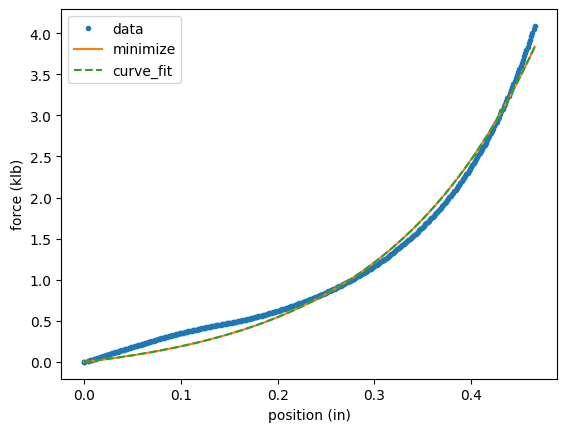

In [15]:
fig, ax = plt.subplots()
ax.plot(position, force, '.', label='data')
ax.plot(position, exp_model(position, a_min, b_min), '-', label='minimize')
ax.plot(position, exp_model(position, a_cf, b_cf), '--', label='curve_fit')
ax.set_xlabel('position (in)')
ax.set_ylabel('force (klb)')
ax.legend()

The curves lie on top of each other.
The residuals from the `minimize` fit still have a pattern, as they did in L19.

Text(0, 0.5, 'residual (klb)')

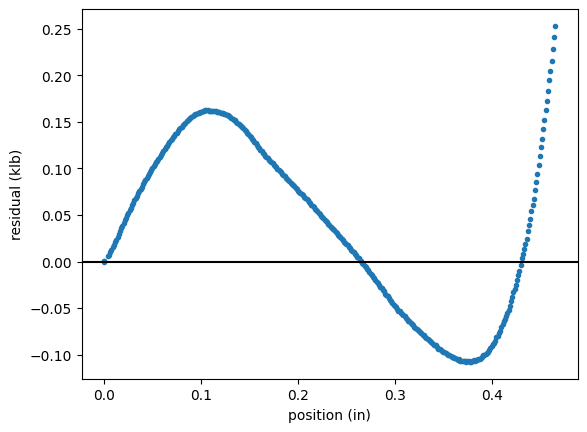

In [16]:
residual_exp = force - exp_model(position, a_min, b_min)

fig, ax = plt.subplots()
ax.plot(position, residual_exp, '.')
ax.axhline(0, color='black')
ax.set_xlabel('position (in)')
ax.set_ylabel('residual (klb)')

The residuals are positive early in the test, negative between about 0.3 and 0.4 in, and positive again at the end.
The objective did not change the shape of the model, so the pattern is still there.
Changing optimizers does not change the model form or remove this residual pattern.

### [Check your understanding]

Fit the power law $F = a x^n$ to the compression data with `minimize`.

1. Write `power_model(x, a, n)` that returns `a * x**n`.
   Write `sum_sq_power(params)` that unpacks `a, n = params`, builds the residuals from `position` and `force`, and returns the sum of their squares.
2. Call `optimize.minimize(sum_sq_power, [15, 2])`.
   The starting values come from the L19 reading of the plot, where the force is about 2.4 klb at 0.4 in.
   Unpack `res.x` into `a_pow, n_pow` and print them with `res.success`.
   How many entries does `x0` have, and what sets that number?
3. Run `optimize.curve_fit(power_model, position, force, p0=[15, 2])`.
   Print both sets of parameters to the same precision.
   Do the displayed values agree, and how does the exponent compare with the 2.4 we got in L19?
4. Run `minimize` again with `x0 = [30, 3]` and print `res.x` and `res.success`.
   Did the second start change the answer?
5. Plot the data and the fitted power law in klb against position.
   Where does the curve sit furthest from the data?

# Summary

* A fit with `minimize` needs an objective function that takes the parameters, builds the model's curve, subtracts it from the data and returns one number.
  The data arrays are read from the notebook.
* The sum of squared residuals is the least-squares objective.
  `curve_fit` minimizes this quantity, so it has the same lowest point as the objective we write.
* `x0` has one starting value per parameter, in the order of the unpack line in the objective.
  `res.x` has one entry per parameter in that same order, and `a_fit, b_fit = res.x` unpacks it.
* `minimize` lets us write any objective.
  `curve_fit` uses the sum of squares only.
  `minimize` returns no `pcov`, so standard errors come from `curve_fit`.
* Cellular solids often pass through bending, collapse and densification, and the printed-part curve has similar regions.
  The exponential model describes the late stage.
  Its fitted values are the same from `minimize` and `curve_fit`, and so is the pattern in its residuals.

## Further reading

* [`scipy.optimize.minimize` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)
* [`scipy.optimize.curve_fit` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), which describes the least-squares objective
* Gibson and Ashby, *Cellular Solids: Structure and Properties*, 2nd ed., Cambridge University Press (1997), for the three stages of compression
* Photo credit: aluminium foam, Stehfun, [CC BY 3.0](https://creativecommons.org/licenses/by/3.0), [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Aluminium_foam.jpg)

# Appendix A: Sum or mean

Optional.
The mean of the squared residuals is the sum divided by the number of readings, 374.
We minimize the mean and compare the parameters with the ones from the sum.

In [17]:
def mean_sq_exp(params):
    a, b = params
    residuals = force - exp_model(position, a, b)
    return np.mean(residuals**2)

res_mean = optimize.minimize(mean_sq_exp, [0.1, 5])
print(f'sum:  a = {a_min:.4f}, b = {b_min:.3f}')
print(f'mean: a = {res_mean.x[0]:.4f}, b = {res_mean.x[1]:.3f}')
print(f'sum / 374 = {res_exp.fun / len(force):.5f}, mean = {res_mean.fun:.5f}')

sum:  a = 0.2151, b = 6.307
mean: a = 0.2151, b = 6.307
sum / 374 = 0.00989, mean = 0.00989


The parameters match to the digits printed.
Dividing an objective by a positive constant leaves its lowest point where it was.
Only the number `res.fun` changes.

# Appendix B: R² from the objective

Optional.
The sum divided by the number of readings is the mean squared error, and its square root is the root-mean-square error, in klb here.
R² is 1 minus the squared misfit over the squared spread of the force, as in L13.
We compute both from `res.fun`.

In [18]:
rmse = np.sqrt(res_exp.fun / len(force))
r2 = 1 - res_exp.fun / (len(force) * np.var(force))
print(f'RMSE = {rmse * 1000:.0f} lb')
print(f'R2 = {r2:.3f}')

RMSE = 99 lb
R2 = 0.990


The R² of 0.99 matches the exponential fit in L19.
`np.var` divides by the number of readings, so multiplying it by 374 gives the squared spread of the force.